# Native PyTorch training

This notebook builds three ordinary PyTorch workflows in sequence:

1. use RHC instead of a gradient optimizer;
2. freeze learned features and use RHC only on a classifier head;
3. use Adam and RHC on different trainable layers of one model.

The single seeded runs demonstrate optimizer composition, not that one optimizer is
generally better than another. Follow the [environment setup](../README.md) before
running. Data, splits, model initialization, and optimizer seeds are fixed. Runs use
CPU, one Torch thread, deterministic operations, and training-only scaling.

In [1]:
import hashlib
import importlib.metadata
import platform
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

import pyperch
from pyperch.plotting import plot_training_curve, prepare_training_curve

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    {
        package: importlib.metadata.version(package)
        for package in ["torch", "numpy", "matplotlib", "scikit-learn", "optuna"]
    }
)
optimizer_dir = Path(pyperch.__file__).parent / "optim"
print(
    "Optimizer SHA256:",
    {
        path.name: hashlib.sha256(path.read_bytes()).hexdigest()[:12]
        for path in sorted(optimizer_dir.glob("*.py"))
    },
)

Python 3.12.13 | Darwin arm64
{'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}
Optimizer SHA256: {'__init__.py': '689555afdfc1', 'base.py': 'cbb9801db916', 'ga.py': '0356d61cd575', 'rhc.py': '5de8c194b8cd', 'sa.py': '100c5c2bab21'}


## 1. Use RHC as the optimizer

A linear model fits a noisy regression target with 25% of observations held out.
The closure returns the current training loss, and `step` evaluates one state or
candidate move. RHC's first call initializes its objective cache, so 200 calls
contain 199 candidate moves.

In [2]:
from sklearn.model_selection import train_test_split

from pyperch.optim import RHC

rng = np.random.default_rng(42)
X = rng.normal(size=(320, 4)).astype("float32")
y = 1.5 * X[:, 0] - X[:, 1] + 0.5 * X[:, 2] + rng.normal(0, 0.2, 320)
y = y.astype("float32")[:, None]
X_train, X_valid, y_train, y_valid = [
    torch.tensor(array)
    for array in train_test_split(X, y, test_size=0.25, random_state=42)
]

torch.manual_seed(42)
model = nn.Linear(4, 1)
loss_fn = nn.MSELoss()
optimizer = RHC(model.parameters(), step_size=0.08, random_state=42)


@torch.no_grad()
def closure():
    return loss_fn(model(X_train), y_train)


losses = {"Train": [], "Validation": []}
for _ in range(200):
    optimizer.step(closure)
    with torch.no_grad():
        losses["Train"].append(loss_fn(model(X_train), y_train).item())
        losses["Validation"].append(loss_fn(model(X_valid), y_valid).item())

optimizer.restore_best()
with torch.no_grad():
    restored_mse = loss_fn(model(X_valid), y_valid).item()
reference_mse = ((y_valid - y_train.mean()) ** 2).mean().item()
print(
    f"Restored validation MSE: {restored_mse:.4f}; "
    f"constant reference: {reference_mse:.4f}"
)
print(
    "Objective calls:",
    optimizer.function_evals,
    "accepted/rejected:",
    optimizer.accepted_steps,
    optimizer.rejected_steps,
)

Restored validation MSE: 0.0486; constant reference: 3.3505
Objective calls: 200 accepted/rejected: 40 159


The curve shows current-model loss measured after each optimizer call.
The dotted line is validation MSE for predicting the training-target mean. This is
one run, so it has no uncertainty band.

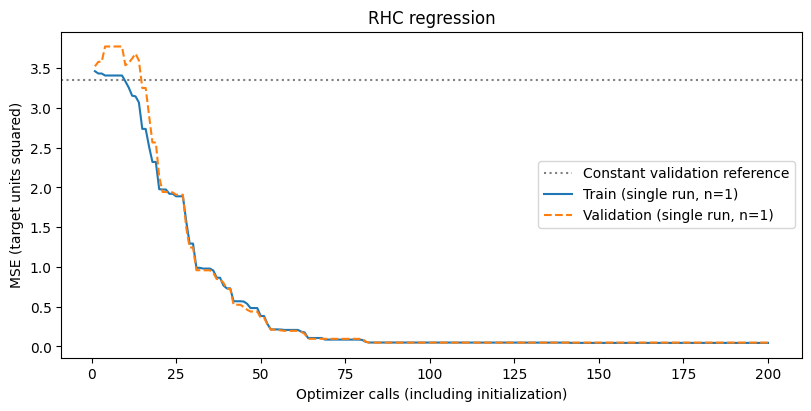

In [3]:
curve = prepare_training_curve(
    np.arange(1, 201),
    losses,
    metric="MSE (target units squared)",
    x_label="Optimizer calls (including initialization)",
)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.axhline(
    reference_mse, color="gray", linestyle=":", label="Constant validation reference"
)
plot_training_curve(curve, ax=ax)
ax.set_title("RHC regression")
plt.show()

## 2. Freeze features and refine the head with RHC

Can I train normally with PyTorch, freeze part of the model, and use RHC on the
remaining parameters?

Start with 16 full-batch Adam updates on a small digits classifier. This deliberately
modest budget learns useful features but stops with validation loss still descending,
well before the model settles. Then freeze both feature layers and pass only the final
classifier parameters to RHC.

In [4]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train_np, X_valid_np, y_train_np, y_valid_np = train_test_split(
    digits.data,
    digits.target,
    test_size=0.25,
    stratify=digits.target,
    random_state=42,
)
scaler = StandardScaler().fit(X_train_np)
X_train = torch.tensor(scaler.transform(X_train_np), dtype=torch.float32)
X_valid = torch.tensor(scaler.transform(X_valid_np), dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
y_valid = torch.tensor(y_valid_np, dtype=torch.long)


def make_model():
    return nn.Sequential(
        nn.Linear(64, 24),
        nn.ReLU(),
        nn.Linear(24, 12),
        nn.ReLU(),
        nn.Linear(12, 10),
    )


@torch.no_grad()
def classification_metrics(model):
    losses = {
        "Train": loss_fn(model(X_train), y_train).item(),
        "Validation": loss_fn(model(X_valid), y_valid).item(),
    }
    validation_accuracy = (model(X_valid).argmax(1) == y_valid).float().mean().item()
    return losses, validation_accuracy


torch.manual_seed(42)
model = make_model()
loss_fn = nn.CrossEntropyLoss()
adam = torch.optim.Adam(model.parameters(), lr=0.01)
initial_losses, _ = classification_metrics(model)
adam_losses = {name: [value] for name, value in initial_losses.items()}

for _ in range(16):
    adam.zero_grad()
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    adam.step()
    current_losses, _ = classification_metrics(model)
    for name in adam_losses:
        adam_losses[name].append(current_losses[name])

before_rhc_losses, before_rhc_accuracy = classification_metrics(model)
feature_parameters = list(model[0].parameters()) + list(model[2].parameters())
frozen_features = [parameter.detach().clone() for parameter in feature_parameters]
for parameter in feature_parameters:
    parameter.requires_grad_(False)

optimizer = RHC(model[4].parameters(), step_size=0.025, random_state=42)


@torch.no_grad()
def closure():
    return loss_fn(model(X_train), y_train)


rhc_losses = {name: [value] for name, value in before_rhc_losses.items()}
for _ in range(151):
    optimizer.step(closure)
    current_losses, _ = classification_metrics(model)
    for name in rhc_losses:
        rhc_losses[name].append(current_losses[name])

optimizer.restore_best()
after_rhc_losses, after_rhc_accuracy = classification_metrics(model)
assert all(
    torch.equal(before, after)
    for before, after in zip(frozen_features, feature_parameters)
)
assert np.isclose(after_rhc_losses["Train"], optimizer.best_loss)
print("Frozen feature parameters unchanged exactly.")
print(
    f"Validation accuracy before RHC: {before_rhc_accuracy:.3f}; "
    f"after restoring RHC's best state: {after_rhc_accuracy:.3f}"
)
print(
    f"Validation loss before RHC: {before_rhc_losses['Validation']:.3f}; "
    f"after restore: {after_rhc_losses['Validation']:.3f}"
)

Frozen feature parameters unchanged exactly.
Validation accuracy before RHC: 0.789; after restoring RHC's best state: 0.820
Validation loss before RHC: 0.834; after restore: 0.699


The saved run reaches 0.789 validation accuracy after Adam, while the loss
curves are still falling. That makes 16 updates a useful partially trained state,
not an Adam baseline carried to convergence. RHC then selects among head-only
changes using training loss. The reported post-RHC metrics are measured only after
`restore_best()`.

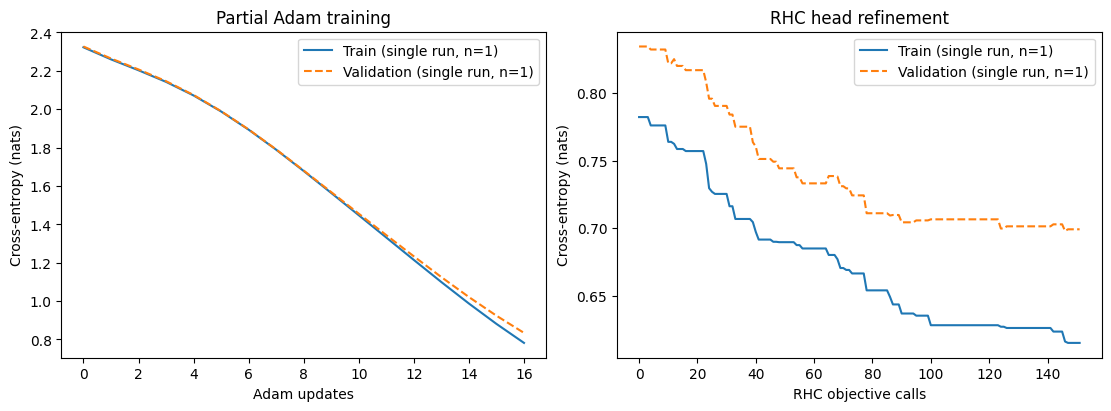

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, x, scores, title, x_label in [
    (
        axes[0],
        np.arange(17),
        adam_losses,
        "Partial Adam training",
        "Adam updates",
    ),
    (
        axes[1],
        np.arange(152),
        rhc_losses,
        "RHC head refinement",
        "RHC objective calls",
    ),
]:
    curve = prepare_training_curve(
        x,
        scores,
        metric="Cross-entropy (nats)",
        x_label=x_label,
    )
    plot_training_curve(curve, ax=ax)
    ax.set_title(title)
plt.show()

## 3. Use Adam and RHC on different layers

Can different optimizers update different parts of the same PyTorch model?

Continue from the restored model. Keep the first feature layer frozen, update the
second feature layer with Adam, and update the classifier with RHC. An Adam update
changes the classifier's objective even though Adam does not own its parameters.
A fresh RHC instance each cycle therefore starts with a valid objective cache.

In [6]:
for parameter in model[2].parameters():
    parameter.requires_grad_(True)

frozen_first_layer = [parameter.detach().clone() for parameter in model[0].parameters()]
adam = torch.optim.Adam(model[2].parameters(), lr=0.002)
hybrid_losses = {name: [value] for name, value in after_rhc_losses.items()}
hybrid_before_accuracy = after_rhc_accuracy

for cycle in range(20):
    model.zero_grad(set_to_none=True)
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    adam.step()

    rhc = RHC(model[4].parameters(), step_size=0.015, random_state=1000 + cycle)
    for _ in range(3):
        rhc.step(closure)
    rhc.restore_best()

    current_losses, _ = classification_metrics(model)
    for name in hybrid_losses:
        hybrid_losses[name].append(current_losses[name])

hybrid_after_losses, hybrid_after_accuracy = classification_metrics(model)
assert all(
    torch.equal(before, after)
    for before, after in zip(frozen_first_layer, model[0].parameters())
)
print("Frozen first-layer parameters unchanged exactly.")
print(
    f"Hybrid validation accuracy before: {hybrid_before_accuracy:.3f}; "
    f"after: {hybrid_after_accuracy:.3f}"
)
print(
    f"Hybrid validation loss before: {after_rhc_losses['Validation']:.3f}; "
    f"after: {hybrid_after_losses['Validation']:.3f}"
)

Frozen first-layer parameters unchanged exactly.
Hybrid validation accuracy before: 0.820; after: 0.842
Hybrid validation loss before: 0.699; after: 0.582


Each cycle contains one Adam update and three RHC objective calls: one
initialization call and two candidate moves. The curve measures loss after complete
cycles, starting from the restored head at cycle 0. It shows continuation on this
fixed run, not a general comparison with Adam or RHC alone.

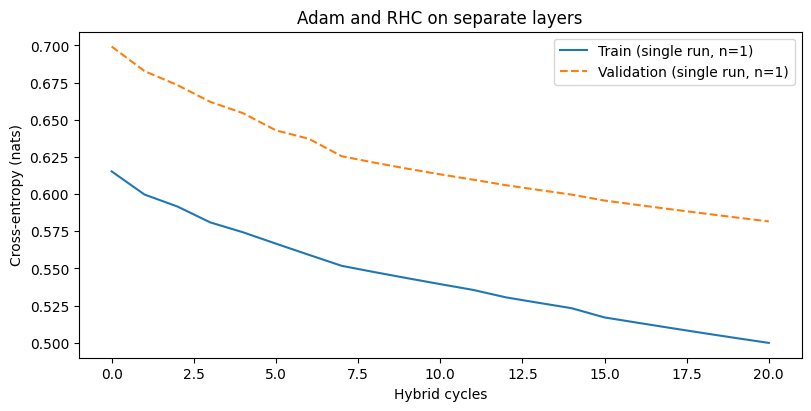

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
curve = prepare_training_curve(
    np.arange(21),
    hybrid_losses,
    metric="Cross-entropy (nats)",
    x_label="Hybrid cycles",
)
plot_training_curve(curve, ax=ax)
ax.set_title("Adam and RHC on separate layers")
plt.show()

Next: [optimizer comparison](02_optimizer_comparison.ipynb).

In [8]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 0.84 seconds
